# Tp 2 - sup : Choix du pas dans la descente de gradient

### Objectifs pédagogiques du TP
Dans cette séance, nous allons étudier l’influence du choix du pas de descente dans les méthodes de gradient.
Les étudiants vont :
1. Implémenter la condition d’Armijo ;
2. Implémenter la méthode de rebroussement (Backtracking) ;
3. Comparer :
    * pas fixe ;
    * Armijo ;
    * rebroussement ;
4. Observer :
    * vitesse de convergence ;
    * stabilité ;
    * qualité de la solution.

### Table
- [1. Rappel théorique](#1)
- [2. Fonction test](#2)
    - [2.1 Descente de gradient avec pas fixe](#2.1)
    - [2.2 Condition d’Armijo](#2.2)
    - [2.3 Méthode de rebroussement](#2.3)
- [3. Descente de gradient avec rebroussement](#3)
- [4. Tableau d’analyse à compléter](#4)

<a name='1'></a>

### 1. Rappel théorique

#### Condition d’Armijo
On dit que $t\geq 0$ satisfait la condition d’Armijo si :
$$f(x+t d) \leq f(x)+\alpha t \langle \nabla f(x), d \rangle$$
avec :
* $0<\alpha<1$
* $d$ direction de descente.

#### Méthode de rebroussement
On cherche un pas :
$$\delta^\star = \beta^N$$
tel que :
$$f(x+\beta^n d) \leq f(x)+\alpha \beta^n \langle \nabla f(x), d\rangle$$

<a name='2'></a>

### 2. Fonction test
Nous allons utiliser une fonction quadratique simple.

**Fonction** : $f(x,y)=x^2+4y^2$
**Gradient** : $\nabla f(x,y)=\begin{bmatrix}2x\\8y\end{bmatrix}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Fonction objectif
# --------------------------------------------------

def f(x):

    return x[0]**2 + 100*x[1]**2

# --------------------------------------------------
# Gradient
# --------------------------------------------------

def grad_f(x):

    return np.array([
        2*x[0],
        200*x[1]
    ])

<a name='2.1'></a>

#### 2.1 Descente de gradient avec pas fixe

**Formule** :
$x^{(k+1)} = x^{(k)} - \eta \nabla f(x^{(k)})$

In [2]:
def gradient_descent_fixed_step(
    x0,
    learning_rate=0.1,
    max_iter=50
):

    x = x0.copy()

    history = [x.copy()]

    for k in range(max_iter):

        # Calcul du gradient
        grad = grad_f(x)

        # Mise à jour
        x = x - learning_rate * grad

        history.append(x.copy())

    return np.array(history)

<a name='2.2'></a>

#### 2.2 Condition d’Armijo

**Principe** :
Nous voulons vérifier si un pas $t$ diminue suffisamment la fonction.

In [3]:
def armijo_condition(
    f,
    grad_f,
    x,
    d,
    t,
    alpha=0.1
):

    # Membre gauche
    left = f(x + t*d)

    # Membre droit
    right = (
        f(x)
        + alpha * t * np.dot(grad_f(x), d)
    )

    return left <= right

<a name='2.3'></a>

#### 2.3 Méthode de rebroussement

**Principe** :
On part d’un grand pas puis on réduit progressivement,
$1,\beta,\beta^2,\beta^3,\dots$
jusqu’à satisfaire l'inégalité.

In [4]:
def backtracking_line_search(
    f,
    grad_f,
    x,
    d,
    alpha=0.1,
    beta=0.5
):

    t = 1.0

    while not armijo_condition(
        f,
        grad_f,
        x,
        d,
        t,
        alpha
    ):

        # Réduction du pas
        t = beta * t

    return t

<a name='3'></a>

### 3. Descente de gradient avec rebroussement

In [5]:
def gradient_descent_backtracking(
    x0,
    max_iter=50
):

    x = x0.copy()

    history = [x.copy()]

    for k in range(max_iter):

        # Gradient
        grad = grad_f(x)

        # Direction de descente
        d = -grad

        # Calcul du pas
        t = backtracking_line_search(
            f,
            grad_f,
            x,
            d
        )

        # Mise à jour
        x = x + t*d

        history.append(x.copy())

    return np.array(history)

Dernier point (pas fixe)
[4.84004854 0.        ]

Dernier point (backtracking)
[2.72922463 0.06301902]


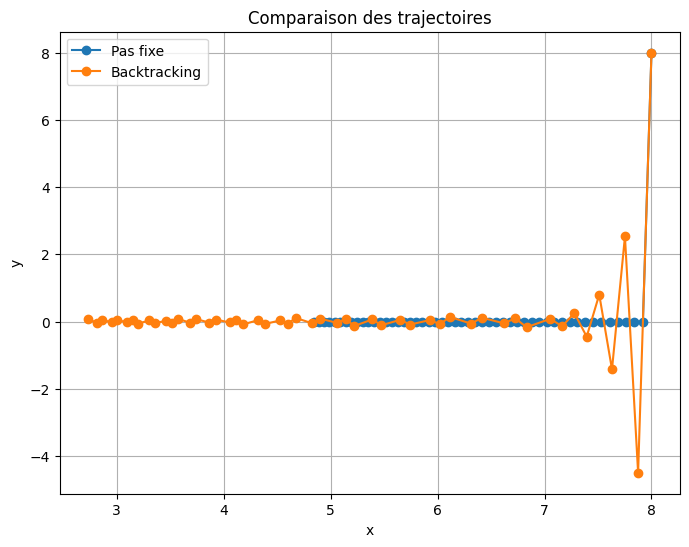

In [11]:
## Exécution des algorithmes
x0 = np.array([8.0,8.0])

# Pas fixe
history_fixed = gradient_descent_fixed_step(
    x0,
    learning_rate=0.005
)

# Backtracking
history_backtracking = gradient_descent_backtracking(
    x0
)

print("Dernier point (pas fixe)")
print(history_fixed[-1])

print("\nDernier point (backtracking)")
print(history_backtracking[-1])

## Visualisation
plt.figure(figsize=(8,6))

plt.plot(
    history_fixed[:,0],
    history_fixed[:,1],
    'o-',
    label='Pas fixe'
)

plt.plot(
    history_backtracking[:,0],
    history_backtracking[:,1],
    'o-',
    label='Backtracking'
)

plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.title(
    "Comparaison des trajectoires"
)

plt.grid()

plt.show()

<a name='4'></a>

### 4. Tableau d’analyse à compléter
**Tableau 1 — Influence du pas fixe**			
| Learning rate $\eta$ | Nombre d’itérations | Stable ? | Rapide ?             | Observation            |
| -------------------- | ------------------- | -------- | -------------------- | ---------------------- |
| 0.001                | Très grand          | Oui      | Non                  | Convergence très lente |
| 0.01                 | Moyen               | Oui      | Moyen                | Bon compromis          |
| 0.1                  | Petit               | Oui      | Oui                  | Convergence rapide     |
| 0.5                  | Faible              | Non      | Très rapide au début | Oscillations           |
| 1.0                  | Impossible          | Non      | Non                  | Divergence             |

**Questions d’analyse**
1. Que se passe-t-il quand le pas est trop petit ?
2. Que se passe-t-il quand le pas est trop grand ?
3. Pourquoi certaines trajectoires oscillent-elles ?

**Tableau 2 — Comparaison des méthodes**
| Méthode            | Choix du pas | Stable   | Rapide | Facile à régler | Observation               |
| ------------------ | ------------ | -------- | ------ | --------------- | ------------------------- |
| Gradient classique | Fixe         | Moyen    | Moyen  | Non             | Sensible au learning rate |
| Armijo             | Adaptatif    | Oui      | Bon    | Oui             | Diminution contrôlée      |
| Rebroussement      | Adaptatif    | Très bon | Bon    | Oui             | Très robuste              |



**Questions théoriques**
- **Question 10**
Pourquoi le rebroussement est-il plus robuste qu’un pas fixe ?

- **Question 11**
Pourquoi un grand pas peut-il provoquer une divergence ?

- **Question 12**
Pourquoi la condition d’Armijo garantit-elle une diminution suffisante de la fonction ?

- **Extension possible**
Tester maintenant sur :
$$f(x,y)=x^2+100y^2$$

    **Questions**
    1. Pourquoi la convergence devient-elle plus difficile ?
    2. Quelle méthode semble la plus robuste ?
    3. Observer les oscillations éventuelles.
